# 02 — Data Quality and Exploratory Analysis

## Overview

This notebook audits the original source alongside the prepared weekly table, exports traceable quality and EDA summaries, and creates five business-facing charts. Missingness and outliers are exposed as review items; they are not presented as evidence of causal media impact.

## Context & Methods

Run Notebook 01 first. Quality checks compare the unchanged source copy with the modelling table so source issues remain visible after documented preparation treatments. Exploratory summaries describe time, promotion, holiday, channel activity, and correlation patterns.

### Key Assumptions

- IQR flags identify review candidates, not automatic deletion rules.
- Correlation describes association and may reflect seasonality, promotion timing, or shared budget decisions; it is not causal evidence.
- Sales summaries exclude only rows where sales are missing and report their sample sizes.
- Channel activity means spend greater than zero after the documented preparation step.

### 1. Set Up the Project Path

In [1]:
from pathlib import Path
import sys

working_directory = Path.cwd().resolve()
PROJECT_ROOT = (
    working_directory.parent
    if working_directory.name.lower() == "notebooks"
    else working_directory
)
if not (PROJECT_ROOT / "src").is_dir():
    raise RuntimeError(
        "Launch this notebook from the project root or the notebooks directory."
    )
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\yifei\Workspace\marketing-mmm-python


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from src.config import get_project_paths
from src.data_prep import MEDIA_COLUMNS
from src.quality import (
    build_issue_register,
    correlation_diagnostics,
    find_date_gaps,
    summarize_data_quality,
)
from src.visualization import (
    plot_channel_spend_activity,
    plot_correlation_heatmap,
    plot_missingness,
    plot_promotion_comparison,
    plot_sales_trend,
)

paths = get_project_paths(PROJECT_ROOT)
paths.charts.mkdir(parents=True, exist_ok=True)
paths.reports.mkdir(parents=True, exist_ok=True)

## Data

### 2. Load Prepared and Original Data

In [3]:
modelling_path = paths.processed / "modelling_ready_data.csv"
source_path = paths.source / "mmm_dataset.csv"
if not modelling_path.exists():
    raise FileNotFoundError("Run Notebook 01 before this notebook.")

modelling_data = pd.read_csv(modelling_path, parse_dates=["date"])
raw_source = pd.read_csv(source_path)
raw_source["date"] = pd.to_datetime(
    raw_source["date"], format="%d-%m-%Y", errors="raise"
)

print(f"Prepared rows: {len(modelling_data):,}")
print(f"Original source rows: {len(raw_source):,}")
display(modelling_data.head(5))

Prepared rows: 209
Original source rows: 209


,date,sales,holiday,sales_promotion,competitor_spend,instagram_spend,google_ads_spend,tv_spend,youtube_spend,newspaper_spend,influencer_spend,ott_spend,instagram_spend_was_missing,google_ads_spend_was_missing,tv_spend_was_missing,youtube_spend_was_missing,newspaper_spend_was_missing,influencer_spend_was_missing,ott_spend_was_missing,competitor_spend_was_missing
0,2022-01-03,1084031.0,0.0,Coupons,237000.0,0.0,94850.0,47580.0,45840.0,0.0,0.0,73570.0,True,False,False,False,True,True,False,False
1,2022-01-10,1225796.0,NaN,NaN,299300.0,0.0,0.0,60140.0,0.0,0.0,0.0,0.0,True,True,False,True,True,True,True,True
2,2022-01-17,1445628.0,0.0,Flash Sale,361600.0,90520.0,0.0,52180.0,30710.0,0.0,48300.0,0.0,False,True,False,False,True,False,True,False
3,2022-01-24,1445965.0,0.0,Normal,293650.0,77800.0,0.0,41940.0,39610.0,0.0,49160.0,0.0,False,True,False,False,True,False,True,False
4,2022-01-31,1370267.0,0.0,Normal,681600.0,180380.0,69560.0,29720.0,84310.0,0.0,54920.0,0.0,False,False,False,False,True,False,True,False


## Results

### 3. Summarise Source Data Quality

In [4]:
quality_columns = ["sales", "holiday", "competitor_spend", *MEDIA_COLUMNS]
quality_summary = summarize_data_quality(raw_source, quality_columns)
quality_summary.to_csv(paths.reports / "data_quality_summary.csv", index=False)
display(quality_summary.round(4))

,column,missing_count,missing_rate,zero_count,zero_rate,negative_count,variance,coefficient_of_variation,outlier_count
0,sales,3,0.0144,0,0.0000,0,1.916320e+11,0.1887,6
1,holiday,0,0.0000,197,0.9426,0,5.440000e-02,4.0615,12
2,competitor_spend,9,0.0431,0,0.0000,0,1.162134e+09,0.1145,0
3,instagram_spend,50,0.2392,0,0.0000,0,2.457473e+08,0.2179,0
4,google_ads_spend,80,0.3828,0,0.0000,0,3.241969e+08,0.1932,0
5,tv_spend,57,0.2727,0,0.0000,0,1.216933e+08,0.2130,0
6,youtube_spend,65,0.3110,0,0.0000,0,1.783061e+08,0.3211,0
7,newspaper_spend,64,0.3062,0,0.0000,0,1.772084e+06,0.1805,0
8,influencer_spend,59,0.2823,0,0.0000,0,1.153829e+08,0.3424,0
9,ott_spend,50,0.2392,0,0.0000,0,1.889166e+08,0.2381,0


In [5]:
total_missing = int(quality_summary["missing_count"].sum())
affected_fields = int((quality_summary["missing_count"] > 0).sum())
display(Markdown(
    f"**Finding.** The source contains **{total_missing} missing numeric values** "
    f"across **{affected_fields} fields**. **Business meaning.** Preparation must "
    "keep an audit trail before filling any media or control values. **Caution.** "
    "A source blank does not universally mean zero activity; that treatment is specific "
    "to this synthetic dataset."
))

**Finding.** The source contains **437 missing numeric values** across **9 fields**. **Business meaning.** Preparation must keep an audit trail before filling any media or control values. **Caution.** A source blank does not universally mean zero activity; that treatment is specific to this synthetic dataset.

### 4. Register Issues and Check Date Gaps

In [6]:
issue_register = build_issue_register(raw_source, modelling_data)
gap_table = find_date_gaps(modelling_data)

In [7]:
issue_register.to_csv(paths.reports / "data_issue_register.csv", index=False)
gap_table.to_csv(paths.reports / "date_gap_table.csv", index=False)

In [8]:
display(issue_register.head(20))
display(gap_table)

,issue_code,source_stage,column,severity,affected_rows,zero_rate,modeling_impact,treatment
0,MISSING_RAW_VALUE,raw,competitor_spend,medium,9,NaN,May require treatment before the variable can ...,Review source extract and document the prepare...
1,MISSING_RAW_VALUE,raw,instagram_spend,medium,50,NaN,May require treatment before the variable can ...,Review source extract and document the prepare...
2,MISSING_RAW_VALUE,raw,google_ads_spend,medium,80,NaN,May require treatment before the variable can ...,Review source extract and document the prepare...
3,MISSING_RAW_VALUE,raw,tv_spend,medium,57,NaN,May require treatment before the variable can ...,Review source extract and document the prepare...
4,MISSING_RAW_VALUE,raw,youtube_spend,medium,65,NaN,May require treatment before the variable can ...,Review source extract and document the prepare...
5,MISSING_RAW_VALUE,raw,newspaper_spend,medium,64,NaN,May require treatment before the variable can ...,Review source extract and document the prepare...
6,MISSING_RAW_VALUE,raw,influencer_spend,medium,59,NaN,May require treatment before the variable can ...,Review source extract and document the prepare...
7,MISSING_RAW_VALUE,raw,ott_spend,medium,50,NaN,May require treatment before the variable can ...,Review source extract and document the prepare...
8,MISSING_TARGET,raw,sales,high,3,NaN,Reduces rows available for model fitting and v...,Exclude from model fitting; retain for reporting
9,PREPARED_ZERO_RATE,prepared,instagram_spend,low,50,0.239234,Low activity or variation may weaken channel c...,Retain zero-spend weeks after media missingnes...


,missing_week


In [9]:
display(Markdown(
    f"**Finding.** The issue register contains **{len(issue_register)} review items**, "
    f"while the prepared calendar has **{len(gap_table)} missing weeks**. "
    "**Business meaning.** A continuous time index is ready for lagged media work. "
    "**Caution.** IQR flags remain diagnostic and are not automatically removed."
))

**Finding.** The issue register contains **19 review items**, while the prepared calendar has **0 missing weeks**. **Business meaning.** A continuous time index is ready for lagged media work. **Caution.** IQR flags remain diagnostic and are not automatically removed.

### 5. Build Correlation Diagnostics

In [10]:
correlation_columns = ["sales", "competitor_spend", *MEDIA_COLUMNS]
correlation_matrix, high_correlation_pairs = correlation_diagnostics(
    modelling_data, correlation_columns, threshold=0.80
)

In [11]:
correlation_matrix.to_csv(paths.reports / "correlation_matrix.csv")
high_correlation_pairs.to_csv(
    paths.reports / "high_correlation_pairs.csv", index=False
)

In [12]:
display(correlation_matrix.round(2))
display(high_correlation_pairs)

,sales,competitor_spend,instagram_spend,google_ads_spend,tv_spend,youtube_spend,newspaper_spend,influencer_spend,ott_spend
sales,1.00,-0.11,0.26,0.42,0.03,0.17,0.06,0.08,0.22
competitor_spend,-0.11,1.00,-0.01,-0.03,0.05,-0.00,0.01,0.06,0.03
instagram_spend,0.26,-0.01,1.00,-0.27,-0.30,0.02,-0.14,0.05,-0.16
google_ads_spend,0.42,-0.03,-0.27,1.00,-0.04,0.16,-0.07,-0.20,-0.00
tv_spend,0.03,0.05,-0.30,-0.04,1.00,-0.14,0.05,0.05,0.08
youtube_spend,0.17,-0.00,0.02,0.16,-0.14,1.00,-0.03,-0.14,-0.09
newspaper_spend,0.06,0.01,-0.14,-0.07,0.05,-0.03,1.00,-0.03,-0.11
influencer_spend,0.08,0.06,0.05,-0.20,0.05,-0.14,-0.03,1.00,-0.11
ott_spend,0.22,0.03,-0.16,-0.00,0.08,-0.09,-0.11,-0.11,1.00


,column_a,column_b,correlation,absolute_correlation


### 6. Create Sales and Promotion Summaries

In [13]:
observed_sales = modelling_data.dropna(subset=["sales"]).copy()
observed_sales["year"] = observed_sales["date"].dt.year
observed_sales["quarter"] = observed_sales["date"].dt.to_period("Q").astype(str)

In [14]:
annual_sales = observed_sales.groupby("year")["sales"].agg(
    total_sales="sum", average_sales="mean", median_sales="median", observed_weeks="size"
).reset_index()
quarterly_sales = observed_sales.groupby("quarter")["sales"].agg(
    total_sales="sum", average_sales="mean", observed_weeks="size"
).reset_index()

In [15]:
sales_quartiles = observed_sales["sales"].quantile([0.25, 0.50, 0.75])
sales_iqr = sales_quartiles.loc[0.75] - sales_quartiles.loc[0.25]
lower_fence = sales_quartiles.loc[0.25] - 1.5 * sales_iqr
upper_fence = sales_quartiles.loc[0.75] + 1.5 * sales_iqr
sales_distribution = pd.DataFrame(
    {
        "metric": ["count", "mean", "median", "std", "iqr", "lower_fence", "upper_fence", "iqr_outliers"],
        "value": [
            len(observed_sales),
            observed_sales["sales"].mean(),
            observed_sales["sales"].median(),
            observed_sales["sales"].std(),
            sales_iqr,
            lower_fence,
            upper_fence,
            int(((observed_sales["sales"] < lower_fence) | (observed_sales["sales"] > upper_fence)).sum()),
        ],
    }
)

In [16]:
promotion_sales = observed_sales.groupby("sales_promotion")["sales"].agg(
    average_sales="mean", median_sales="median", observed_weeks="size"
).sort_values("average_sales", ascending=False).reset_index()
holiday_sales = observed_sales.groupby("holiday")["sales"].agg(
    average_sales="mean", median_sales="median", observed_weeks="size"
).reset_index()
holiday_sales["period"] = holiday_sales["holiday"].map(
    {0: "Non-holiday", 1: "Holiday"}
)

In [17]:
annual_sales.to_csv(paths.reports / "annual_sales_summary.csv", index=False)
quarterly_sales.to_csv(paths.reports / "quarterly_sales_summary.csv", index=False)
sales_distribution.to_csv(paths.reports / "sales_distribution_summary.csv", index=False)
promotion_sales.to_csv(paths.reports / "promotion_sales_summary.csv", index=False)
holiday_sales.to_csv(paths.reports / "holiday_sales_summary.csv", index=False)

In [18]:
display(annual_sales.round(1))
display(quarterly_sales.tail(8).round(1))
display(sales_distribution.round(2))
display(promotion_sales.round(1))
display(holiday_sales[["period", "average_sales", "median_sales", "observed_weeks"]].round(1))

,year,total_sales,average_sales,median_sales,observed_weeks
0,2022,123205635.0,2415796.8,2501527.0,51
1,2023,107532154.0,2108473.6,2226527.0,51
2,2024,128004628.0,2461627.5,2395853.0,52
3,2025,119159744.0,2291533.5,2360668.5,52


,quarter,total_sales,average_sales,observed_weeks
8,2024Q1,33286963.0,2560535.6,13
9,2024Q2,29970160.0,2305396.9,13
10,2024Q3,35001645.0,2692434.2,13
11,2024Q4,29745860.0,2288143.1,13
12,2025Q1,32152904.0,2473300.3,13
13,2025Q2,31055785.0,2388906.5,13
14,2025Q3,26149192.0,2011476.3,13
15,2025Q4,29801863.0,2292451.0,13


,metric,value
0,count,206.0
1,mean,2319913.4
2,median,2362322.5
3,std,437757.9
4,iqr,532127.0
5,lower_fence,1293459.0
6,upper_fence,3421967.0
7,iqr_outliers,6.0


,sales_promotion,average_sales,median_sales,observed_weeks
0,Coupons,2392405.4,2391273.0,64
1,BOGO,2377368.9,2404310.5,48
2,Flash Sale,2273174.7,2362028.0,15
3,Normal,2235150.5,2313007.0,79


,period,average_sales,median_sales,observed_weeks
0,Non-holiday,2318597.6,2360919.0,194
1,Holiday,2341185.5,2459462.5,12


In [19]:
best_promotion = promotion_sales.iloc[0]
holiday_lookup = holiday_sales.set_index("period")
holiday_difference = (
    holiday_lookup.loc["Holiday", "average_sales"]
    - holiday_lookup.loc["Non-holiday", "average_sales"]
)
display(Markdown(
    f"**Finding.** **{best_promotion['sales_promotion']}** has the highest observed "
    f"average sales at **{best_promotion['average_sales']:,.0f}**, and holiday weeks "
    f"average **{holiday_difference:,.0f}** more sales than non-holiday weeks. "
    "**Business meaning.** Promotion and holiday controls belong in the model. "
    "**Caution.** These are unadjusted group comparisons, not incremental lift estimates."
))

**Finding.** **Coupons** has the highest observed average sales at **2,392,405**, and holiday weeks average **22,588** more sales than non-holiday weeks. **Business meaning.** Promotion and holiday controls belong in the model. **Caution.** These are unadjusted group comparisons, not incremental lift estimates.

### 7. Summarise Channel Activity

In [20]:
recent_window = modelling_data.tail(13)
channel_rows = []
for channel in MEDIA_COLUMNS:
    spend = pd.to_numeric(modelling_data[channel], errors="raise")
    active_spend = spend[spend > 0]
    channel_rows.append(
        {
            "channel": channel,
            "total_spend": float(spend.sum()),
            "historical_active_mean": float(active_spend.mean()) if len(active_spend) else 0.0,
            "median_active_week_spend": float(active_spend.median()) if len(active_spend) else 0.0,
            "active_weeks": int((spend > 0).sum()),
            "active_rate": float((spend > 0).mean()),
            "current_weekly_budget": float(recent_window[channel].mean()),
        }
    )
channel_summary = pd.DataFrame(channel_rows).sort_values(
    "total_spend", ascending=False
).reset_index(drop=True)
channel_summary.to_csv(paths.reports / "channel_summary.csv", index=False)
display(channel_summary.round(3))

spend_sales = modelling_data[["date", "sales", *MEDIA_COLUMNS]].copy()
spend_sales["total_media_spend"] = spend_sales[MEDIA_COLUMNS].sum(axis=1)
spend_sales_correlation = spend_sales[["total_media_spend", "sales"]].corr().iloc[0, 1]
display(spend_sales[["date", "total_media_spend", "sales"]].tail(8))

,channel,total_spend,historical_active_mean,median_active_week_spend,active_weeks,active_rate,current_weekly_budget
0,google_ads_spend,12024860.0,93215.969,92830.0,129,0.617,29310.000
1,instagram_spend,11440220.0,71951.069,70760.0,159,0.761,71049.231
2,ott_spend,9180190.0,57737.044,57220.0,159,0.761,56830.769
3,tv_spend,7870450.0,51779.276,52175.0,152,0.727,53427.692
4,youtube_spend,5989090.0,41590.903,42670.0,144,0.689,29692.308
5,influencer_spend,4706220.0,31374.800,31930.0,150,0.718,14886.154
6,newspaper_spend,1069650.0,7376.897,7320.0,145,0.694,5162.308


,date,total_media_spend,sales
201,2025-11-10,318750.0,2535608.0
202,2025-11-17,277070.0,2502857.0
203,2025-11-24,364010.0,2624574.0
204,2025-12-01,260870.0,2824619.0
205,2025-12-08,329810.0,2747119.0
206,2025-12-15,305200.0,2676494.0
207,2025-12-22,267030.0,2489367.0
208,2025-12-29,259750.0,2299871.0


In [21]:
leading_channel = channel_summary.iloc[0]
display(Markdown(
    f"**Finding.** **{leading_channel['channel'].replace('_', ' ').title()}** has the "
    f"largest total spend at **{leading_channel['total_spend']:,.0f}**. Total weekly "
    f"media spend has a **{spend_sales_correlation:.2f}** raw correlation with sales. "
    "**Business meaning.** Channel scale and timing need multivariate adjustment. "
    "**Caution.** Spend-sales correlation is directional context only."
))

**Finding.** **Google Ads Spend** has the largest total spend at **12,024,860**. Total weekly media spend has a **0.68** raw correlation with sales. **Business meaning.** Channel scale and timing need multivariate adjustment. **Caution.** Spend-sales correlation is directional context only.

### 8. Save and Display the Five Business Charts

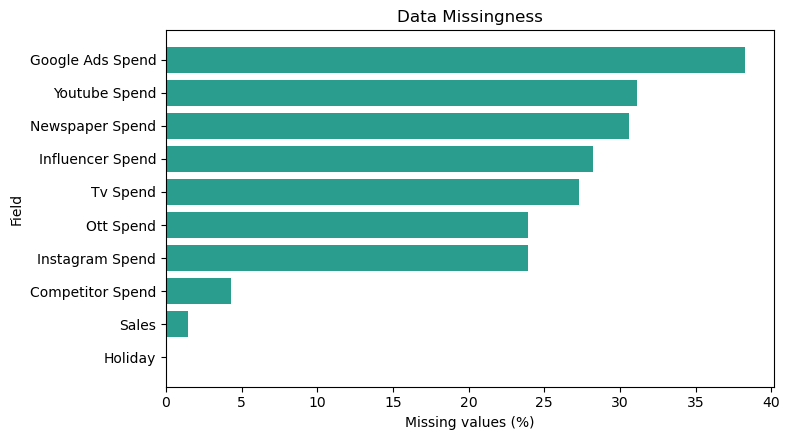

In [22]:
axes = plot_missingness(
    quality_summary, paths.charts / "data_missingness.png"
)
plt.show()
plt.close(axes.figure)

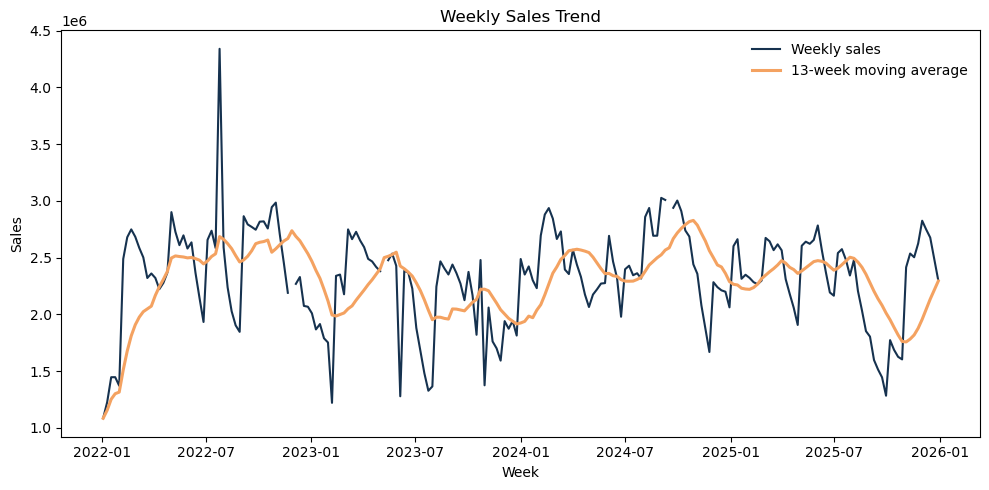

In [23]:
axes = plot_sales_trend(
    modelling_data, paths.charts / "weekly_sales_trend.png"
)
plt.show()
plt.close(axes.figure)

In [24]:
first_13_week_average = observed_sales.head(13)["sales"].mean()
last_13_week_average = observed_sales.tail(13)["sales"].mean()
display(Markdown(
    f"**Finding.** The observed 13-week average moves from **{first_13_week_average:,.0f}** "
    f"at the start to **{last_13_week_average:,.0f}** at the end. **Business meaning.** "
    "Trend and seasonality should be controlled before interpreting media coefficients. "
    "**Caution.** The series is synthetic and contains three retained target gaps."
))

**Finding.** The observed 13-week average moves from **2,072,013** at the start to **2,292,451** at the end. **Business meaning.** Trend and seasonality should be controlled before interpreting media coefficients. **Caution.** The series is synthetic and contains three retained target gaps.

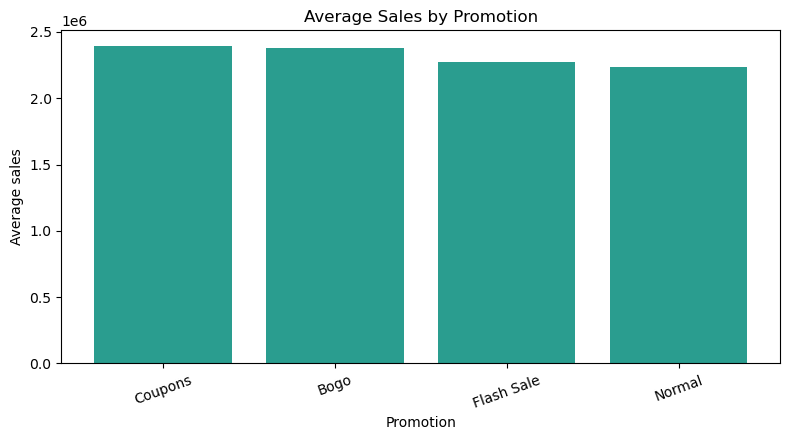

In [25]:
axes = plot_promotion_comparison(
    modelling_data, paths.charts / "promotion_sales_comparison.png"
)
plt.show()
plt.close(axes.figure)

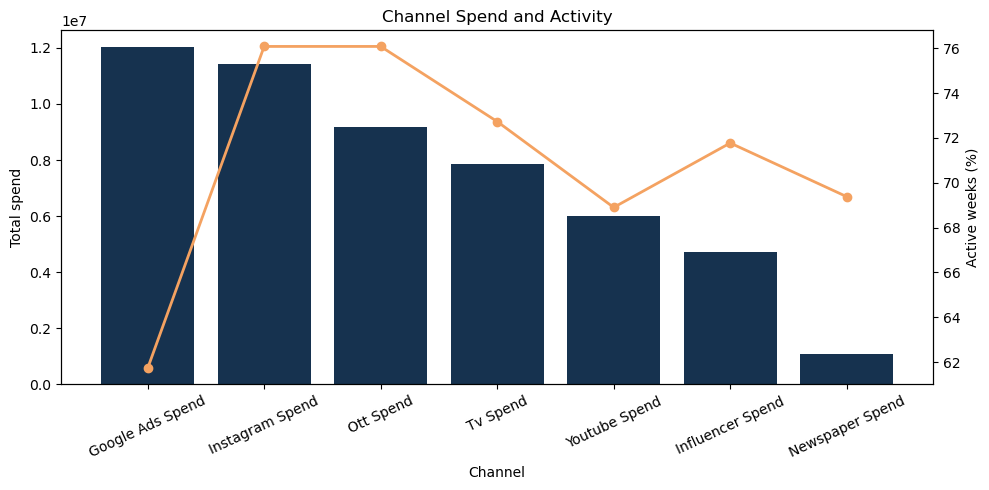

In [26]:
axes = plot_channel_spend_activity(
    channel_summary, paths.charts / "channel_spend_activity.png"
)
plt.show()
plt.close(axes.figure)

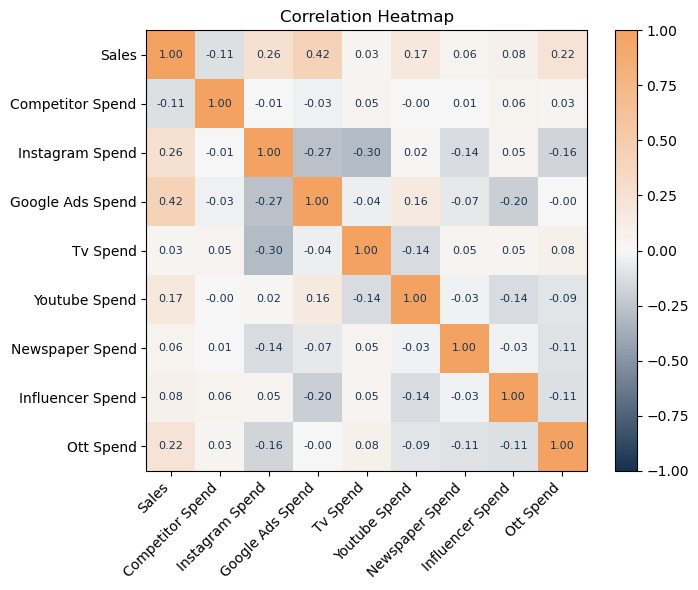

In [27]:
axes = plot_correlation_heatmap(
    correlation_matrix, paths.charts / "correlation_heatmap.png"
)
plt.show()
plt.close(axes.figure)

In [28]:
if high_correlation_pairs.empty:
    pair_evidence = "No pairs meet the absolute 0.80 threshold"
else:
    strongest_pair = high_correlation_pairs.iloc[0]
    pair_evidence = (
        f"{strongest_pair['column_a']} and {strongest_pair['column_b']} have the "
        f"largest flagged absolute correlation ({strongest_pair['absolute_correlation']:.2f})"
    )
display(Markdown(
    f"**Finding.** {pair_evidence}. **Business meaning.** Ridge regularisation is a "
    "reasonable guard against unstable coefficients in this small educational model. "
    "**Caution.** Regularisation does not make the result causal."
))

**Finding.** No pairs meet the absolute 0.80 threshold. **Business meaning.** Ridge regularisation is a reasonable guard against unstable coefficients in this small educational model. **Caution.** Regularisation does not make the result causal.

## Takeaways

- The prepared table is weekly and gap-free while the source issue register preserves missingness and outlier review items.
- Promotion, holiday, trend, seasonality, and competitor activity are plausible controls for the simplified model.
- EDA patterns are descriptive. Model contributions and proxy ROI in the next notebook remain directional estimates based on synthetic data.